# Redes Neuronales vs. Modelos de Ensemble en Datos Tabulares
## Predicción de Rotación de Empleados — *Employee Attrition*

**Asignatura:** Redes Neuronales  
**Autores:** Josselyn Bonilla Albán, Marcos Gibert Robles  
**Dataset:** Job Change of Data Scientists (HR Analytics)

---

### Objetivo

Investigamos si una **Red Neuronal Artificial (ANN)** correctamente diseñada puede igualar el rendimiento de modelos de ensemble (**Random Forest**, **XGBoost**) en un dataset tabular de tamaño moderado.

> *¿Puede una ANN bien diseñada competir con modelos de árboles y gradient boosting en datos tabulares estructurados?*

**Metodología (resumen):**
1. Baseline naive como punto de partida (ANN sin ingeniería).
2. Ingeniería de características (codificación ordinal + indicadores de *missingness*).
3. Comparación rigurosa con **validación cruzada estratificada**, *pipelines* sin fuga de datos y métricas adecuadas para clases desbalanceadas (F1, ROC-AUC, **PR-AUC**).
4. Interpretabilidad mediante **SHAP**.


## 1. Importaciones y configuración

In [1]:
import os, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, cross_val_predict)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, roc_auc_score,
                             average_precision_score, roc_curve,
                             precision_recall_curve)
import shap

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"TensorFlow {tf.__version__}")

TensorFlow 2.20.0


## 2. Datos y exploración

El dataset recoge candidatos que han completado cursos de formación de una empresa de ciencia de datos. La variable objetivo `Target` indica si el candidato busca cambiar de empleo (1) o no (0). Es un problema de **clasificación binaria con clases desbalanceadas** (~75% / ~25%).

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/attrition.csv')
print(f"Dimensiones: {df.shape}")

# Diagnóstico rápido: tipos, nulos y cardinalidad
resumen = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'pct_nulos': (df.isna().mean() * 100).round(1),
    'n_unicos': df.nunique()
}).sort_values('pct_nulos', ascending=False)
resumen

Dimensiones: (19158, 14)


,tipo,pct_nulos,n_unicos
Company_type,object,32.0,6
Company_size,object,31.0,8
Gender,object,23.5,3
Major_discipline,object,14.7,6
Education_level,object,2.4,5
Last_new_job,object,2.2,6
Enrolled_university,object,2.0,3
Experience,object,0.3,22
Enrollee_id,int64,0.0,19158
City,object,0.0,123


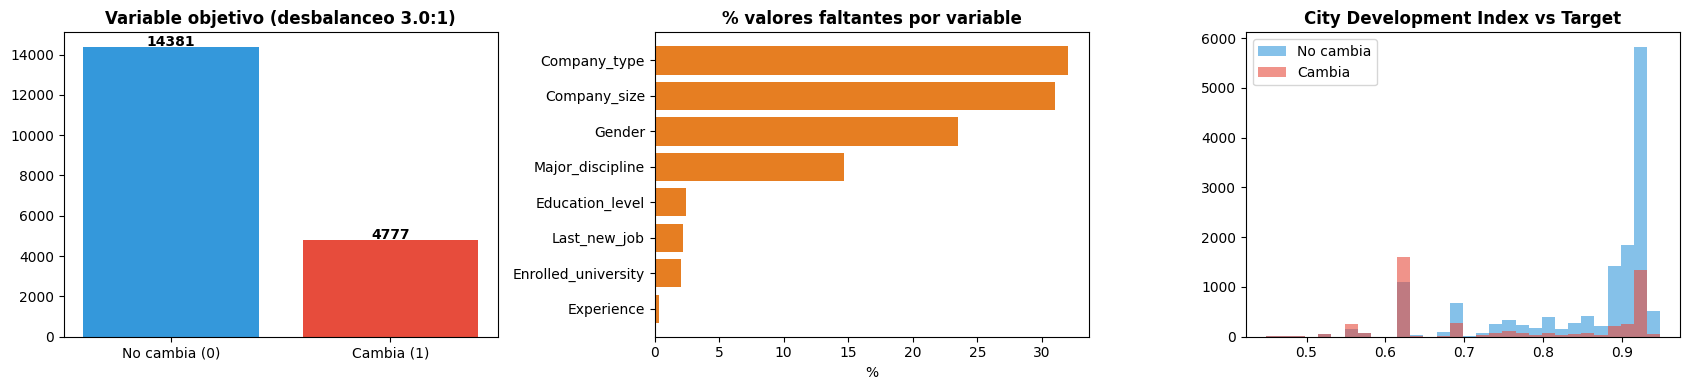

In [4]:
# EDA compacto: target, nulos y dos variables clave
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

tc = df['Target'].value_counts().sort_index()
axes[0].bar(['No cambia (0)', 'Cambia (1)'], tc.values, color=['#3498db', '#e74c3c'])
axes[0].set_title(f'Variable objetivo (desbalanceo {tc[0]/tc[1]:.1f}:1)', fontweight='bold')
for i, v in enumerate(tc.values):
    axes[0].text(i, v+50, str(v), ha='center', fontweight='bold')

miss = (df.isna().mean()*100)
miss = miss[miss > 0].sort_values()
axes[1].barh(miss.index, miss.values, color='#e67e22')
axes[1].set_title('% valores faltantes por variable', fontweight='bold')
axes[1].set_xlabel('%')

axes[2].hist(df[df['Target']==0]['City_development_index'], bins=30, alpha=0.6, color='#3498db', label='No cambia')
axes[2].hist(df[df['Target']==1]['City_development_index'], bins=30, alpha=0.6, color='#e74c3c', label='Cambia')
axes[2].set_title('City Development Index vs Target', fontweight='bold')
axes[2].legend()

plt.tight_layout(); plt.show()

**Observaciones clave:** (1) la clase positiva es minoritaria, por lo que el `accuracy` es engañoso y priorizamos **F1, ROC-AUC y PR-AUC**; (2) varias variables (`Company_type`, `Company_size`, `Gender`) tienen muchos nulos — trataremos la *ausencia* como información, no como ruido; (3) `City_development_index` separa visiblemente las clases.

## 3. Ingeniería de características

Aplicamos transformaciones **deterministas** (no dependen de la distribución de los datos, por lo que no causan fuga):

- **Codificación ordinal** para variables con orden natural (`Experience`, `Education_level`, `Last_new_job`, `Company_size`).
- **Indicadores de *missingness***: una columna binaria por variable con nulos. No revelar el tipo o tamaño de empresa puede correlacionar con la búsqueda de empleo, así que el dato faltante es informativo.
- **One-Hot** para nominales sin orden.

La **imputación por mediana** y la **estandarización** se dejan *fuera* de este paso y se integran en un `Pipeline` de scikit-learn, de modo que se ajustan únicamente con datos de entrenamiento dentro de cada *fold* de validación cruzada (evitando fuga de datos).

In [6]:
df = pd.read_csv('/content/drive/MyDrive/attrition.csv').drop(columns=['Enrollee_id', 'City'])

# Codificación ordinal (orden natural)
exp_map  = {'<1': 0, **{str(i): i for i in range(1, 21)}, '>20': 21}
edu_map  = {'Primary School': 0, 'High School': 1, 'Graduate': 2, 'Masters': 3, 'Phd': 4}
ljob_map = {'never': 0, '1': 1, '2': 2, '3': 3, '4': 4, '>4': 5}
csize_map= {'<10': 0, '10/49': 1, '50-99': 2, '100-500': 3, '500-999': 4,
            '1000-4999': 5, '5000-9999': 6, '10000+': 7}
df['Experience']      = df['Experience'].map(exp_map)
df['Education_level'] = df['Education_level'].map(edu_map)
df['Last_new_job']    = df['Last_new_job'].map(ljob_map)
df['Company_size']    = df['Company_size'].map(csize_map)
df['Relevent_experience'] = (df['Relevent_experience'] == 'Has relevent experience').astype(int)

# Indicadores de missingness (el dato faltante es informativo)
for c in ['Gender', 'Enrolled_university', 'Major_discipline', 'Company_type',
          'Company_size', 'Experience', 'Last_new_job', 'Education_level']:
    df[f'{c}_missing'] = df[c].isnull().astype(int)

# One-Hot para nominales
nominals = ['Gender', 'Enrolled_university', 'Major_discipline', 'Company_type']
for c in nominals:
    df[c] = df[c].fillna('Missing')
df = pd.get_dummies(df, columns=nominals, drop_first=True)
df = df.astype({c: int for c in df.columns if df[c].dtype == bool})

X = df.drop(columns=['Target'])
y = df['Target']
feat_names = list(X.columns)
print(f"Variables tras ingeniería: {X.shape[1]}")

Variables tras ingeniería: 33


In [7]:
# División estratificada train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

# Preprocesador (imputación + escalado) — se ajusta SOLO con train dentro del pipeline
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

n0, n1 = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = n0 / n1
class_weight_ann = {0: n0/(2*n0), 1: n0/(2*n1)}
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | clase 1: {y_train.mean():.1%}")

Train: 15326 | Test: 3832 | clase 1: 24.9%


## 4. Funciones auxiliares

`umbral_optimo_f1` selecciona el umbral sobre datos de validación (nunca sobre test) para evitar optimismo. `metricas` resume el desempeño con énfasis en la clase positiva.

In [8]:
def umbral_optimo_f1(y_true, y_proba):
    ths = np.linspace(0.1, 0.9, 81)
    f1s = [f1_score(y_true, (y_proba >= t).astype(int)) for t in ths]
    return ths[int(np.argmax(f1s))]

def metricas(nombre, y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    r = classification_report(y_true, y_pred, output_dict=True)
    return {'Modelo': nombre,
            'F1 (clase 1)':  round(r['1']['f1-score'], 3),
            'Precision (1)': round(r['1']['precision'], 3),
            'Recall (1)':    round(r['1']['recall'], 3),
            'ROC-AUC':       round(roc_auc_score(y_true, y_proba), 3),
            'PR-AUC':        round(average_precision_score(y_true, y_proba), 3),
            'Accuracy':      round(r['accuracy'], 3),
            'Umbral':        round(threshold, 2)}

resultados = []

## 5. Punto de partida — ANN *baseline* naive

Entrenamos una ANN con la **misma arquitectura** que usaremos después (64→32→16) pero **sin ingeniería de características, sin estandarización y sin pesos de clase**: solo `LabelEncoder` arbitrario e imputación bruta. Sirve para aislar el impacto real de las decisiones de ingeniería (no de la arquitectura).

In [10]:
# Preprocesamiento naive sobre datos crudos
df_naive = pd.read_csv('/content/drive/MyDrive/attrition.csv').drop(columns=['Enrollee_id', 'City'])
for c in df_naive.select_dtypes(include='object').columns:
    df_naive[c] = df_naive[c].fillna(df_naive[c].mode()[0])
for c in df_naive.select_dtypes(include='number').columns:
    df_naive[c] = df_naive[c].fillna(df_naive[c].median())
for c in df_naive.select_dtypes(include='object').columns:
    df_naive[c] = LabelEncoder().fit_transform(df_naive[c])

Xn, yn = df_naive.drop(columns=['Target']), df_naive['Target']
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(Xn, yn, test_size=0.2, random_state=SEED, stratify=yn)
# validación para umbral
Xn_f, Xn_v, yn_f, yn_v = train_test_split(Xn_tr, yn_tr, test_size=0.2, random_state=SEED, stratify=yn_tr)

tf.random.set_seed(SEED); np.random.seed(SEED)
ann_naive = Sequential([
    Dense(64, activation='relu', input_dim=Xn_tr.shape[1]),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1,  activation='sigmoid')
], name='ANN_Baseline')
ann_naive.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann_naive.fit(Xn_f, yn_f, validation_data=(Xn_v, yn_v),
              epochs=50, batch_size=32, verbose=0)  # sin class_weight

pv = ann_naive.predict(Xn_v, verbose=0).flatten()
t_base = umbral_optimo_f1(yn_v, pv)
pe = ann_naive.predict(Xn_te, verbose=0).flatten()
print(classification_report(yn_te, (pe >= t_base).astype(int), target_names=['No cambia','Cambia']))
resultados.append(metricas('ANN Baseline (naive)', yn_te, pe, t_base))

              precision    recall  f1-score   support

   No cambia       0.89      0.63      0.74      2877
      Cambia       0.41      0.77      0.53       955

    accuracy                           0.66      3832
   macro avg       0.65      0.70      0.63      3832
weighted avg       0.77      0.66      0.69      3832



**Diagnóstico:** el baseline naive obtiene un F1 de clase 1 modesto y un ROC-AUC en torno a 0.74-0.75. Sin pesos de clase ni codificación semántica, el modelo discrimina mal la clase minoritaria. Esto motiva las mejoras siguientes.

## 6. Modelos de referencia con validación cruzada

Para situar a la ANN frente a alternativas sólidas, comparamos cuatro modelos clásicos mediante **validación cruzada estratificada de 5 *folds*** sobre el conjunto de entrenamiento. Esto da estimaciones robustas (media ± desviación) en lugar de depender de una sola partición:

- **Dummy** — suelo mínimo honesto (predice siempre la clase mayoritaria).
- **Regresión logística** — referencia lineal interpretable.
- **Random Forest** y **XGBoost** — ensembles no lineales, los modelos a batir.

In [11]:
modelos_clasicos = {
    'Dummy':         DummyClassifier(strategy='most_frequent'),
    'Logística':     LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                            class_weight='balanced', random_state=SEED, n_jobs=-1),
    'XGBoost':       XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                   subsample=0.8, colsample_bytree=0.8,
                                   scale_pos_weight=scale_pos_weight,
                                   eval_metric='logloss', random_state=SEED),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = ['f1', 'roc_auc', 'average_precision']

cv_rows = []
for nombre, clf in modelos_clasicos.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    s = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        'Modelo': nombre,
        'F1 (CV)':     f"{s['test_f1'].mean():.3f} ± {s['test_f1'].std():.3f}",
        'ROC-AUC (CV)':f"{s['test_roc_auc'].mean():.3f} ± {s['test_roc_auc'].std():.3f}",
        'PR-AUC (CV)': f"{s['test_average_precision'].mean():.3f} ± {s['test_average_precision'].std():.3f}",
    })
pd.DataFrame(cv_rows)

,Modelo,F1 (CV),ROC-AUC (CV),PR-AUC (CV)
0,Dummy,0.000 ± 0.000,0.500 ± 0.000,0.249 ± 0.000
1,Logística,0.574 ± 0.012,0.776 ± 0.007,0.513 ± 0.010
2,Random Forest,0.614 ± 0.012,0.793 ± 0.008,0.532 ± 0.013
3,XGBoost,0.621 ± 0.011,0.792 ± 0.010,0.535 ± 0.016


In [12]:
# Evaluación final en test. Umbral elegido por validación cruzada (out-of-fold), nunca sobre test.
for nombre, clf in modelos_clasicos.items():
    if nombre == 'Dummy':
        continue
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    oof = cross_val_predict(pipe, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
    t = umbral_optimo_f1(y_train, oof)
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    resultados.append(metricas(nombre, y_test, proba, t))
    if nombre == 'Random Forest': proba_rf, pipe_rf = proba, pipe
    if nombre == 'XGBoost':       proba_xgb, pipe_xgb = proba, pipe

pd.DataFrame([r for r in resultados if r['Modelo'] in ['Random Forest','XGBoost','Logística']])

,Modelo,F1 (clase 1),Precision (1),Recall (1),ROC-AUC,PR-AUC,Accuracy,Umbral
0,Logística,0.593,0.489,0.754,0.785,0.514,0.742,0.53
1,Random Forest,0.638,0.551,0.757,0.807,0.538,0.785,0.44
2,XGBoost,0.639,0.564,0.737,0.814,0.550,0.793,0.55


## 7. ANN mejorada

Aplicamos sobre la red las técnicas que cierran la brecha con los ensembles:

| Técnica | Propósito |
|---|---|
| Ingeniería de características (ordinal + *missingness*) | Aporta señal que el baseline naive no captura |
| `StandardScaler` (en *pipeline*) | Convergencia estable de gradientes |
| `class_weight` balanceado | Evita ignorar la clase minoritaria |
| Arquitectura compacta 64→32→16 | Menos capacidad de memorización |
| BatchNorm + Dropout (0.4) + L2 (5e-4) | Regularización contra el sobreajuste |
| Adam + `ReduceLROnPlateau` + Early stopping | Optimización adaptativa y parada en el óptimo de validación |

El umbral de clasificación se selecciona sobre un conjunto de **validación** (no sobre test).

In [13]:
# Preprocesado ajustado solo con train; validación interna para early stopping y umbral
X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_p, y_train, test_size=0.2, random_state=SEED, stratify=y_train)

tf.random.set_seed(SEED); np.random.seed(SEED)
ann = Sequential([
    Dense(64, activation='relu', kernel_initializer='he_uniform',
          kernel_regularizer=l2(5e-4), input_dim=X_train_p.shape[1]),
    BatchNormalization(), Dropout(0.4),
    Dense(32, activation='relu', kernel_initializer='he_uniform', kernel_regularizer=l2(5e-4)),
    BatchNormalization(), Dropout(0.4),
    Dense(16, activation='relu', kernel_initializer='he_uniform', kernel_regularizer=l2(5e-4)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='ANN_Mejorada')
ann.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy',
            metrics=[tf.keras.metrics.AUC(name='auc')])

callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=4, min_lr=1e-5)
]
history = ann.fit(X_fit, y_fit, validation_data=(X_val, y_val),
                  epochs=100, batch_size=128, class_weight=class_weight_ann,
                  callbacks=callbacks, verbose=0)
print(f"Detenido en época {len(history.history['loss'])}")

Detenido en época 47


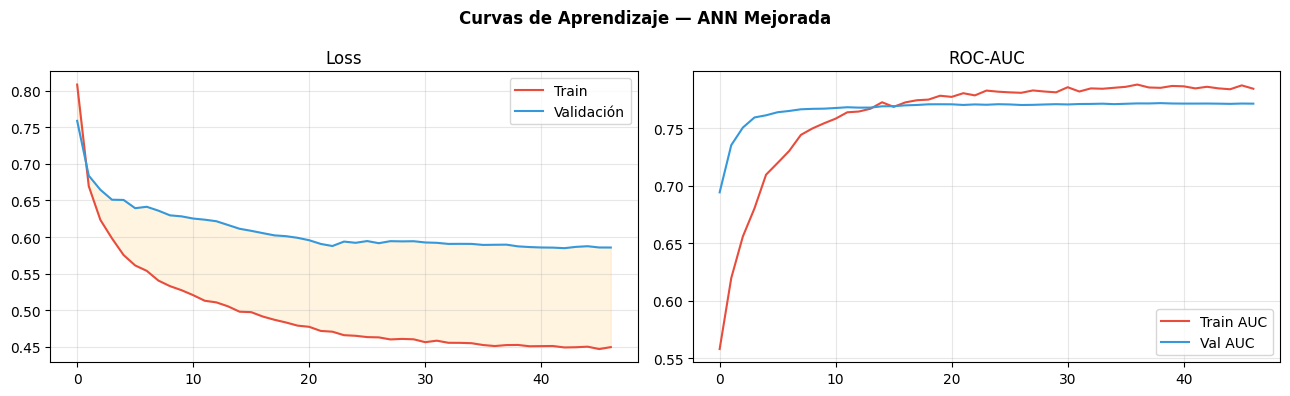

In [14]:
# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(len(history.history['loss']))
axes[0].plot(ep, history.history['loss'], color='#e74c3c', label='Train')
axes[0].plot(ep, history.history['val_loss'], color='#3498db', label='Validación')
axes[0].fill_between(ep, history.history['loss'], history.history['val_loss'],
                     alpha=0.12, color='orange')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, history.history['auc'], color='#e74c3c', label='Train AUC')
axes[1].plot(ep, history.history['val_auc'], color='#3498db', label='Val AUC')
axes[1].set_title('ROC-AUC'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle('Curvas de Aprendizaje — ANN Mejorada', fontweight='bold')
plt.tight_layout(); plt.show()

In [15]:
# Evaluación de la ANN mejorada (umbral por validación)
proba_val = ann.predict(X_val, verbose=0).flatten()
t_ann = umbral_optimo_f1(y_val, proba_val)
proba_ann = ann.predict(X_test_p, verbose=0).flatten()
print(classification_report(y_test, (proba_ann >= t_ann).astype(int), target_names=['No cambia','Cambia']))
resultados.append(metricas('ANN Mejorada', y_test, proba_ann, t_ann))

              precision    recall  f1-score   support

   No cambia       0.91      0.75      0.82      2877
      Cambia       0.51      0.77      0.61       955

    accuracy                           0.76      3832
   macro avg       0.71      0.76      0.72      3832
weighted avg       0.81      0.76      0.77      3832



**Sobre el sobreajuste.** Existe una brecha entre las curvas de train y validación, esperable al pasar a Adam con mayor capacidad de aprendizaje. Reflej­a el **trade-off sesgo-varianza**: la regularización aplicada no busca eliminar la brecha sino gestionarla, priorizando la capacidad de aprendizaje sin que la varianza dañe la generalización. La brecha residual es en parte estructural en datos tabulares de tamaño moderado (Grinsztajn et al., 2022).

## 8. Comparación global

Reunimos todos los modelos. La métrica principal es el **F1 de clase 1**; complementamos con **ROC-AUC** (discriminación global) y **PR-AUC** (desempeño sobre la clase positiva bajo desbalanceo).

In [16]:
tabla = pd.DataFrame(resultados).set_index('Modelo')
orden = ['ANN Baseline (naive)', 'Logística', 'ANN Mejorada', 'Random Forest', 'XGBoost']
tabla = tabla.reindex([m for m in orden if m in tabla.index])
tabla

,F1 (clase 1),Precision (1),Recall (1),ROC-AUC,PR-AUC,Accuracy,Umbral
Modelo,,,,,,,
ANN Baseline (naive),0.533,0.407,0.770,0.754,0.481,0.663,0.12
Logística,0.593,0.489,0.754,0.785,0.514,0.742,0.53
ANN Mejorada,0.612,0.509,0.769,0.801,0.536,0.757,0.57
Random Forest,0.638,0.551,0.757,0.807,0.538,0.785,0.44
XGBoost,0.639,0.564,0.737,0.814,0.550,0.793,0.55


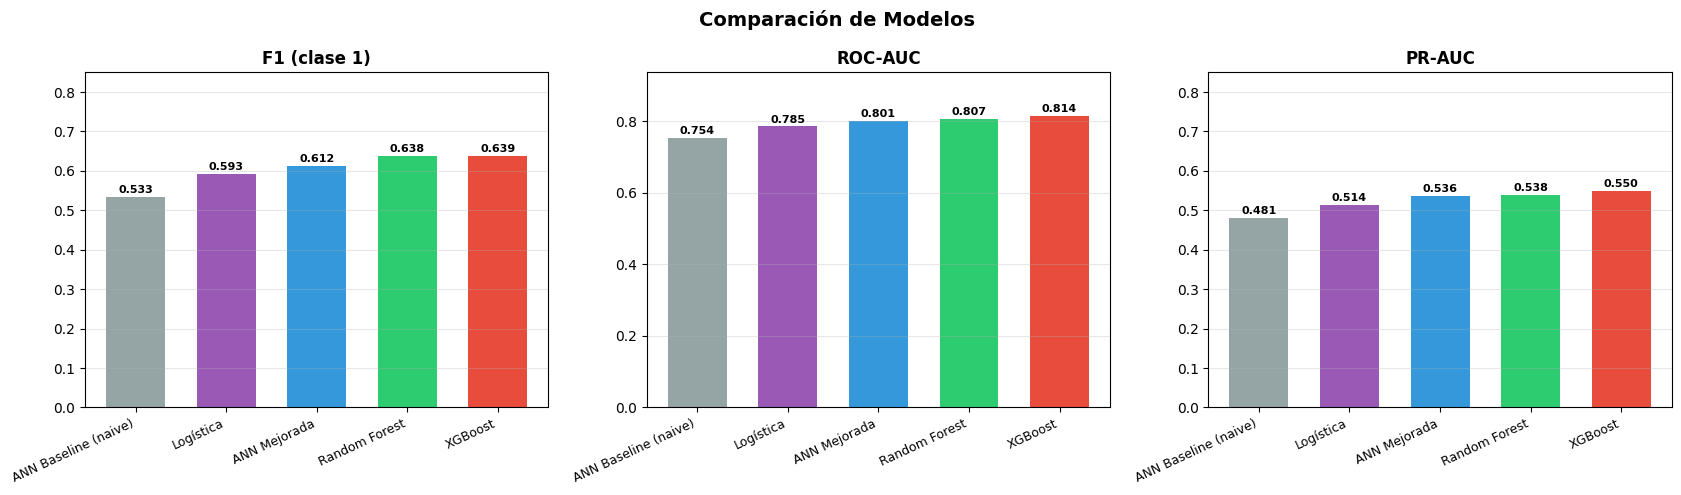

In [17]:
# Barras de las tres métricas clave
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colores = {'ANN Baseline (naive)':'#95a5a6','Logística':'#9b59b6','ANN Mejorada':'#3498db',
           'Random Forest':'#2ecc71','XGBoost':'#e74c3c'}
cols = [colores[m] for m in tabla.index]
for ax, met in zip(axes, ['F1 (clase 1)', 'ROC-AUC', 'PR-AUC']):
    ax.bar(range(len(tabla)), tabla[met], color=cols, width=0.65)
    ax.set_xticks(range(len(tabla))); ax.set_xticklabels(tabla.index, rotation=25, ha='right', fontsize=9)
    ax.set_title(met, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(0.85, tabla[met].max()*1.15))
    for i, v in enumerate(tabla[met]):
        ax.text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
plt.suptitle('Comparación de Modelos', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

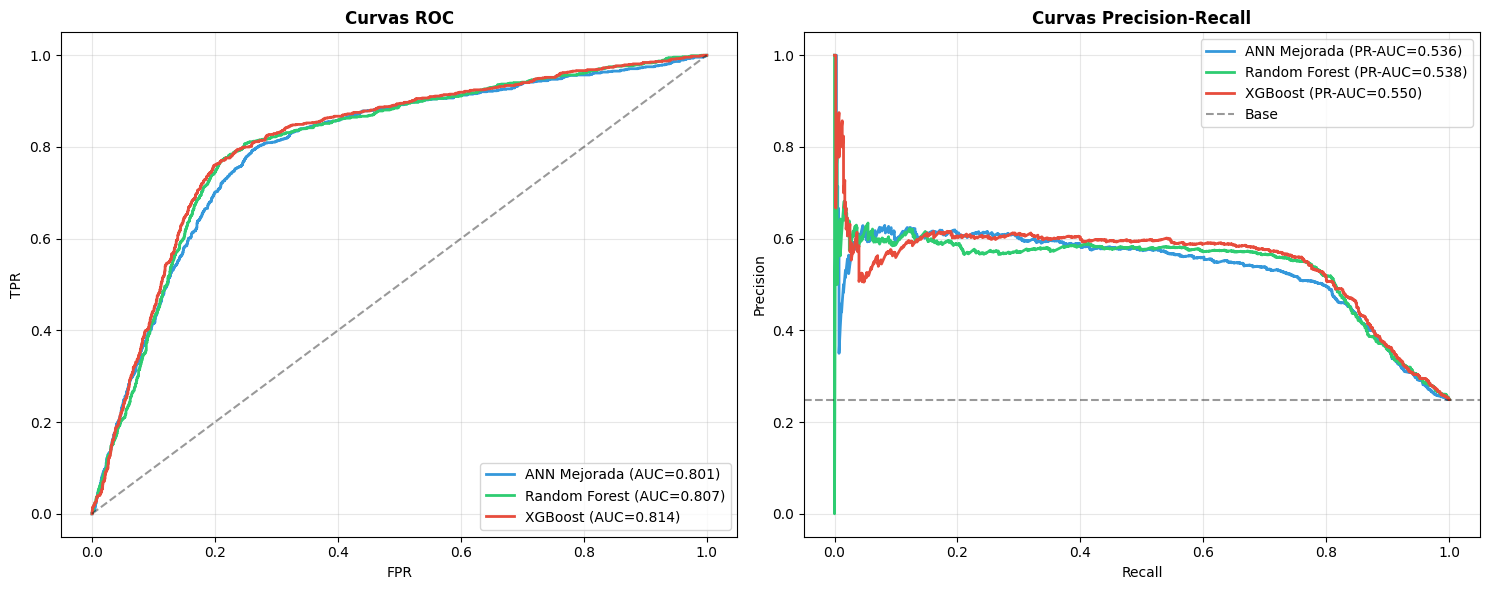

In [18]:
# Curvas ROC y Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
curvas = [('ANN Mejorada', proba_ann, '#3498db'),
          ('Random Forest', proba_rf, '#2ecc71'),
          ('XGBoost', proba_xgb, '#e74c3c')]
for nombre, p, c in curvas:
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, color=c, lw=2, label=f'{nombre} (AUC={roc_auc_score(y_test,p):.3f})')
axes[0].plot([0,1],[0,1],'k--',alpha=0.4)
axes[0].set_title('Curvas ROC', fontweight='bold'); axes[0].legend(loc='lower right')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].grid(alpha=0.3)
for nombre, p, c in curvas:
    pr, rc, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rc, pr, color=c, lw=2, label=f'{nombre} (PR-AUC={average_precision_score(y_test,p):.3f})')
axes[1].axhline(y_test.mean(), ls='--', color='k', alpha=0.4, label='Base')
axes[1].set_title('Curvas Precision-Recall', fontweight='bold'); axes[1].legend(loc='upper right')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Lectura.** La ANN mejorada salta del baseline naive a un F1 ~0.61 y ROC-AUC ~0.80, situándose entre la regresión logística y los ensembles, a ~0.02-0.03 puntos de XGBoost. **Iguala prácticamente a Random Forest pero no supera a XGBoost**, resultado coherente con la literatura sobre datos tabulares (Grinsztajn et al., 2022): los modelos de árboles mantienen ventaja estructural en datasets de tamaño moderado. El salto principal proviene de la **ingeniería de características**, no de la arquitectura.

## 9. Interpretabilidad — SHAP

Compensamos la opacidad de la ANN con un análisis SHAP. Para los modelos de árboles usamos `TreeExplainer` (exacto y rápido); para la ANN, **importancia por permutación** (alternativa robusta). Comparamos qué considera importante cada modelo.

In [19]:
# Muestra para SHAP
np.random.seed(SEED)
idx = np.random.choice(len(X_test_p), 500, replace=False)
X_shap = X_test_p[idx]

xgb_clf = pipe_xgb.named_steps['clf']
rf_clf  = pipe_rf.named_steps['clf']

xgb_shap = shap.TreeExplainer(xgb_clf).shap_values(X_shap)
rf_raw   = shap.TreeExplainer(rf_clf).shap_values(X_shap)
rf_shap  = rf_raw[:, :, 1] if rf_raw.ndim == 3 else rf_raw

# Permutation importance para la ANN
base_auc = roc_auc_score(y_test, proba_ann)
rng = np.random.RandomState(SEED)
perm = []
for j in range(X_test_p.shape[1]):
    Xp = X_test_p.copy(); Xp[:, j] = rng.permutation(Xp[:, j])
    perm.append(base_auc - roc_auc_score(y_test, ann.predict(Xp, verbose=0, batch_size=512).flatten()))
perm = np.array(perm)
print("SHAP / permutation listos")

SHAP / permutation listos


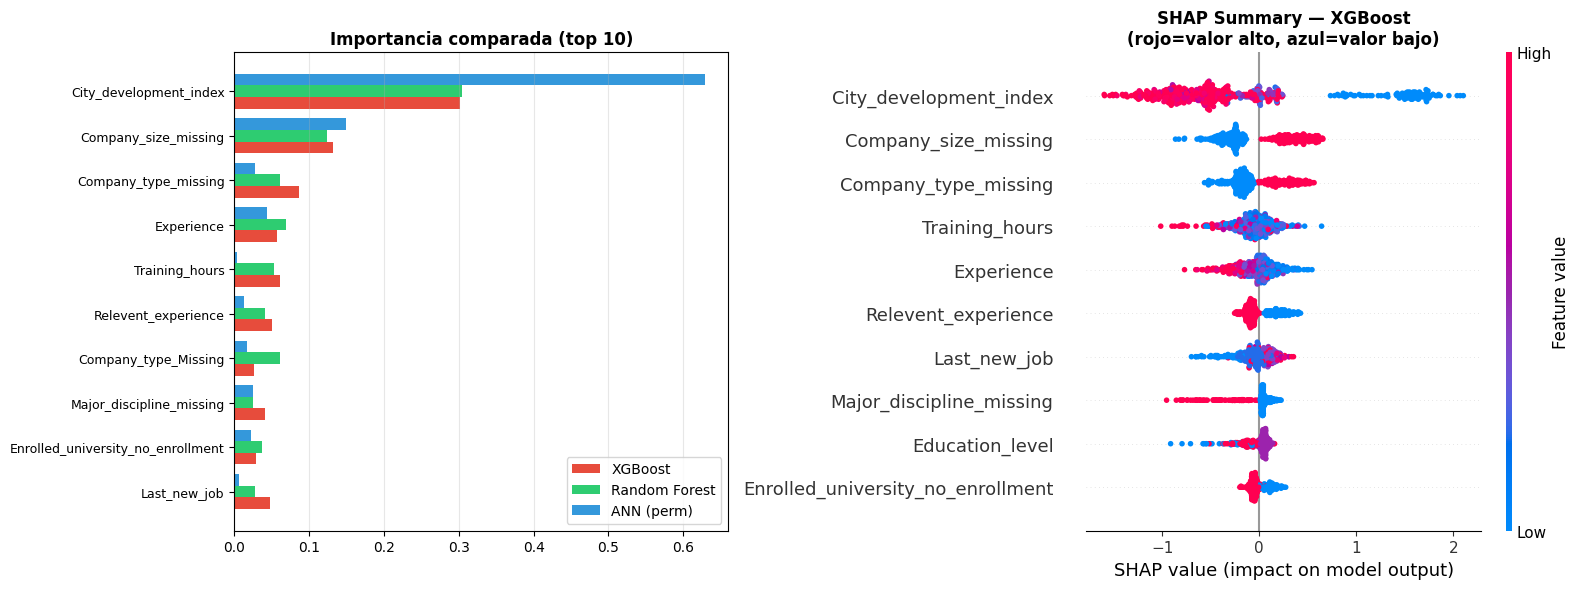

In [20]:
# Importancia comparada (top 10) + beeswarm de XGBoost
def norm(x):
    x = np.clip(x, 0, None); return x/x.sum() if x.sum() > 0 else x
imp = pd.DataFrame({'Feature': feat_names,
                    'XGBoost': norm(np.abs(xgb_shap).mean(0)),
                    'Random Forest': norm(np.abs(rf_shap).mean(0)),
                    'ANN (perm)': norm(perm)})
imp['m'] = imp[['XGBoost','Random Forest','ANN (perm)']].mean(1)
top = imp.sort_values('m').tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
yp = np.arange(len(top)); w = 0.26
axes[0].barh(yp-w, top['XGBoost'], w, label='XGBoost', color='#e74c3c')
axes[0].barh(yp,   top['Random Forest'], w, label='Random Forest', color='#2ecc71')
axes[0].barh(yp+w, top['ANN (perm)'], w, label='ANN (perm)', color='#3498db')
axes[0].set_yticks(yp); axes[0].set_yticklabels(top['Feature'], fontsize=9)
axes[0].set_title('Importancia comparada (top 10)', fontweight='bold')
axes[0].legend(loc='lower right'); axes[0].grid(axis='x', alpha=0.3)

plt.sca(axes[1])
shap.summary_plot(xgb_shap, X_shap, feature_names=feat_names, max_display=10, show=False, plot_size=None)
axes[1].set_title('SHAP Summary — XGBoost\n(rojo=valor alto, azul=valor bajo)', fontweight='bold')
plt.tight_layout(); plt.show()

**Concordancia entre modelos.** Los tres coinciden en los predictores dominantes, lo que indica que aprenden patrones reales y no artefactos:

1. **`City_development_index`** — predictor más fuerte en todos; ciudades menos desarrolladas se asocian a mayor probabilidad de cambio.
2. **Indicadores de *missingness*** (`Company_size_missing`, `Company_type_missing`) — no revelar información de la empresa actual predice búsqueda de empleo. Esta señal solo existe gracias a la ingeniería de características y es invisible para un preprocesamiento naive.
3. **`Experience`** — más experiencia se asocia a menor probabilidad de cambio.

Que la ANN (vía permutación) coincida con los ensembles (vía SHAP) sugiere que **ha aprendido representaciones coherentes**, pese a su mayor opacidad interna.

## 10. Conclusiones

**Respuesta a la pregunta central:** una ANN bien diseñada **iguala prácticamente a Random Forest y queda muy cerca de XGBoost** (~0.02-0.03 en F1/AUC), pero **no lo supera**. Es un resultado honesto y alineado con la literatura: en datos tabulares de tamaño moderado, los ensembles de árboles conservan ventaja estructural.

**Qué marca la diferencia.** El salto de rendimiento provino de la **ingeniería de características** (codificación ordinal + indicadores de *missingness*) y del tratamiento del desbalanceo, no de una arquitectura más profunda. *En datos tabulares, el preprocesamiento importa más que la arquitectura.*

**Rigor metodológico.** Validación cruzada estratificada, *pipelines* sin fuga de datos, selección de umbral en validación y métricas sensibles al desbalanceo (PR-AUC) sostienen las conclusiones.

**Limitaciones y trabajo futuro.**
- ~19k muestras es un tamaño modesto para ANNs; con más datos la brecha podría reducirse.
- Brecha de generalización residual (sobreajuste parcial), intrínseca al caso tabular.
- Arquitecturas específicas para datos tabulares (**TabNet**, **FT-Transformer**) podrían cerrar o invertir la brecha.

### Referencias
- Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). *Why do tree-based models still outperform deep learning on tabular data?* NeurIPS.
- Lundberg, S. M., & Lee, S. I. (2017). *A unified approach to interpreting model predictions.* NeurIPS.
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow.* O'Reilly.
